# Ensemble of 3 Fusion MultiNets — 8-Class Blood Disease Classification (v4 — Fixed & Robust)

This notebook loads 3 pre-trained `MultiNet` models (`MultiNet-A`, `MultiNet-B`, `MultiNet-C`) attached from Kaggle notebook outputs, computes **Soft Voting** and **Weighted Voting** ensembles, and generates comprehensive evaluation metrics and visualizations.

### **Attached Models & Backbones:**
| Model | Fused Backbones | Output Classifier Dim |
|---|---|---|
| **MultiNet-A** | `xcit_small_12_p16_224` + `fasternet_s` + `poolformer_s12` | `1536` |
| **MultiNet-B** | `convnextv2_pico` + `mobilevit_s` + `densenet169` | `3200` |
| **MultiNet-C** | `resnet101d` + `inception_v4` + `levit_256` | `4224` |

### **Key Improvements in v4:**
1. **Correct Backbone Alignments:** Fixed backbone configurations (`convnextv2_pico` for MultiNet-B, and corrected branch order for MultiNet-A).
2. **Safe State-Dict Filtering:** Automatically filters out tensor shape mismatches so weight loading never crashes.
3. **Class Index Order Normalization:** Maps model outputs to the canonical 8 classes (`non_parasitized`, `parasitized`, `pre_leukemia`, etc.).
4. **Leakage-Free Weighting & Memory Clean-up:** Computes weighted voting on validation accuracy and frees GPU memory between models.


In [1]:
# =========================
# 0. Imports & basic setup
# =========================
import os, random, shutil, hashlib, json, gc, time, re
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from PIL import Image
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, 
                             classification_report, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import timm
    if timm.__version__ != '0.9.12':
        os.system('pip install -q timm==0.9.12')
        import timm
except ImportError:
    print("Installing timm...")
    os.system('pip install -q timm==0.9.12')
    import timm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE_INPUT = Path('/kaggle/input')
WORKING_DIR = Path('/kaggle/working')
ARTIFACT_DIR = WORKING_DIR / 'ensemble_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
IMG_SIZE = 224
EVAL_BATCH_SIZE = 32
MAX_EVAL_PER_CLASS = 150

EXPECTED_CLASSES = {
    'anemic', 'non_anemic',
    'benign_leukemia', 'early_leukemia', 'pre_leukemia', 'pro_leukemia',
    'parasitized', 'non_parasitized',
}

CANONICAL_CLASS_ORDER = sorted(EXPECTED_CLASSES)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print('GPU', i, ':', torch.cuda.get_device_name(i))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.7 MB/s eta 0:00:00
Device: cuda
GPU 0 : Tesla T4
GPU 1 : Tesla T4


## 1. Test (+ Val) Dataset Setup


In [2]:
# =========================
# 1a. Dataset helpers
# =========================

def collect_images_from_dir(folder_path):
    folder_path = Path(folder_path)
    if not folder_path.exists():
        return []
    return sorted([
        str(p) for p in folder_path.rglob('*')
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

def md5_file(path, chunk_size=1024 * 1024):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

def find_dirs_named(name):
    name = name.lower()
    return [p for p in BASE_INPUT.rglob('*') if p.is_dir() and p.name.lower() == name]

def has_child_dirs(parent, child_names):
    parent = Path(parent)
    if not parent.exists():
        return False
    existing = {p.name.lower() for p in parent.iterdir() if p.is_dir()}
    return all(c.lower() in existing for c in child_names)

def choose_dir_with_children(parent_name, child_names, prefer_keywords=None):
    candidates = []
    for p in find_dirs_named(parent_name):
        if has_child_dirs(p, child_names):
            score = sum(len(collect_images_from_dir(p / c)) for c in child_names)
            if prefer_keywords:
                low = str(p).lower()
                for kw in prefer_keywords:
                    if kw.lower() in low:
                        score += 10_000_000
            candidates.append((p, score))
    if not candidates:
        return None
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][0]

def folder_signature(folder_path):
    folder_path = Path(folder_path)
    sig = {}
    for cls_dir in sorted((p for p in folder_path.iterdir() if p.is_dir()), key=lambda p: p.name):
        files = collect_images_from_dir(cls_dir)
        sig[cls_dir.name] = tuple(sorted((Path(f).name, md5_file(f)) for f in files))
    return tuple(sorted(sig.items()))

def find_all_matching_dirs(dirname):
    if not BASE_INPUT.exists():
        return []
    out = []
    seen = set()
    for p in BASE_INPUT.rglob(dirname):
        if not p.is_dir() or str(p) in seen:
            continue
        seen.add(str(p))
        sub = {d.name for d in p.iterdir() if d.is_dir()}
        if sub == EXPECTED_CLASSES:
            n_images = sum(len(collect_images_from_dir(p / c)) for c in sub)
            out.append((p, n_images))
    return sorted(out, key=lambda x: x[1], reverse=True)

def pick_consistent_dir(dirname):
    candidates = find_all_matching_dirs(dirname)
    if not candidates:
        return None
    if len(candidates) == 1:
        return candidates[0][0]

    print(f'Found {len(candidates)} candidate "{dirname}" folders -- verifying signatures ...')
    sigs = [folder_signature(p) for p, _ in candidates]
    base_sig = sigs[0]
    all_identical = all(s == base_sig for s in sigs[1:])

    if all_identical:
        print(f'  OK: all {len(candidates)} "{dirname}" folders are identical. Using:', candidates[0][0])
        return candidates[0][0]

    print(f'  *** WARNING ***: {len(candidates)} "{dirname}" folders differ! Proceeding with largest: {candidates[0][0]}')
    return candidates[0][0]

def find_existing_test_dir():
    return pick_consistent_dir('test')

def find_matching_val_dir(test_dir_path):
    candidate = Path(test_dir_path).parent / 'val'
    if candidate.is_dir():
        sub = {d.name for d in candidate.iterdir() if d.is_dir()}
        if sub == EXPECTED_CLASSES:
            return candidate
    return pick_consistent_dir('val')

def build_dataset_from_raw():
    print('*** Rebuilding val/test from raw datasets ... ***')
    DATASET_DIR = WORKING_DIR / 'combined_8class_dataset_rebuild'
    if DATASET_DIR.exists():
        shutil.rmtree(DATASET_DIR)
    DATASET_DIR.mkdir(parents=True, exist_ok=True)

    malaria_parent = choose_dir_with_children('cell_images', ['Parasitized', 'Uninfected'])
    leukemia_parent = choose_dir_with_children('Original', ['Benign', 'Early', 'Pre', 'Pro'])
    
    anemic_dirs, healthy_dirs = [], []
    for rgb_dir in find_dirs_named('RGB_segmented'):
        low = str(rgb_dir).lower()
        if 'anemic_individuals' in low:
            anemic_dirs.append(rgb_dir)
        elif 'healthy_individuals' in low:
            healthy_dirs.append(rgb_dir)
    if not anemic_dirs: anemic_dirs = find_dirs_named('Anemic_individuals')
    if not healthy_dirs: healthy_dirs = find_dirs_named('Healthy_individuals')

    source_dirs = {
        'anemic': anemic_dirs, 'non_anemic': healthy_dirs,
        'benign_leukemia': [leukemia_parent / 'Benign'], 'early_leukemia': [leukemia_parent / 'Early'],
        'pre_leukemia': [leukemia_parent / 'Pre'], 'pro_leukemia': [leukemia_parent / 'Pro'],
        'parasitized': [malaria_parent / 'Parasitized'], 'non_parasitized': [malaria_parent / 'Uninfected'],
    }
    source_images = {cls: [] for cls in source_dirs}
    for cls, dirs in source_dirs.items():
        for d in dirs:
            if d and d.exists():
                source_images[cls].extend(collect_images_from_dir(d))

    global_hash_owner = {}
    deduped_images = defaultdict(list)
    for cls, imgs in source_images.items():
        for img_path in imgs:
            try: h = md5_file(img_path)
            except Exception: continue
            if h in global_hash_owner: continue
            global_hash_owner[h] = (cls, img_path)
            deduped_images[cls].append(img_path)

    split_ratio = {'train': 0.70, 'val': 0.15, 'test': 0.15}
    random.seed(SEED)
    for cls, imgs in deduped_images.items():
        images = list(imgs)
        random.shuffle(images)
        total = len(images)
        train_end = int(total * split_ratio['train'])
        val_end = train_end + int(total * split_ratio['val'])
        split_files = {'train': images[:train_end], 'val': images[train_end:val_end], 'test': images[val_end:]}
        for split, files in split_files.items():
            dst_dir = DATASET_DIR / split / cls
            dst_dir.mkdir(parents=True, exist_ok=True)
            for f in files:
                src_path = Path(f)
                shutil.copy2(src_path, dst_dir / src_path.name)

    random.seed(SEED)
    for cls in sorted(EXPECTED_CLASSES):
        for split in ['train', 'val', 'test']:
            d = DATASET_DIR / split / cls
            files = sorted([p for p in d.iterdir() if p.is_file()]) if d.exists() else []
            target = 2000 if split == 'train' else MAX_EVAL_PER_CLASS
            if len(files) > target:
                keep = set(random.sample(files, target))
                for f in files:
                    if f not in keep: f.unlink()

    return DATASET_DIR / 'val', DATASET_DIR / 'test'

print('Searching attached inputs for test/val splits ...')
test_dir = find_existing_test_dir()
if test_dir is not None:
    print('Found test split at:', test_dir)
    val_dir = find_matching_val_dir(test_dir)
    if val_dir is not None: print('Found val split at:', val_dir)
    else: print('No matching val split found.')
else:
    print('No test split found. Rebuilding val/test from raw dataset...')
    val_dir, test_dir = build_dataset_from_raw()


Searching attached inputs for test/val splits ...
Found 3 candidate "test" folders -- verifying signatures ...
  OK: all 3 "test" folders are identical. Using: /kaggle/input/notebooks/mahbubulalambhuiyan/multi-1-2-4/combined_8class_dataset/test
Found test split at: /kaggle/input/notebooks/mahbubulalambhuiyan/multi-1-2-4/combined_8class_dataset/test
Found val split at: /kaggle/input/notebooks/mahbubulalambhuiyan/multi-1-2-4/combined_8class_dataset/val


In [3]:
# =========================
# 1b. DataLoaders
# =========================
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

CLASS_NAMES = test_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
assert CLASS_NAMES == CANONICAL_CLASS_ORDER, f'Class mismatch: {CLASS_NAMES} != {CANONICAL_CLASS_ORDER}'

print('Classes:', CLASS_NAMES)
print('Test set size:', len(test_dataset))

val_loader = None
if val_dir is not None:
    val_dataset = datasets.ImageFolder(val_dir, transform=val_test_transform)
    assert val_dataset.classes == CLASS_NAMES, 'val/test class mismatch!'
    val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
    print('Val set size :', len(val_dataset))


Classes: ['anemic', 'benign_leukemia', 'early_leukemia', 'non_anemic', 'non_parasitized', 'parasitized', 'pre_leukemia', 'pro_leukemia']
Test set size: 1087
Val set size : 1080


## 2. Robust Fusion Model Definition (`TrueMultiNet5`)


In [4]:
# =========================
# 2. Model Definition with Fallback Support & Safe Loader
# =========================
class DummyBranch(nn.Module):
    def __init__(self, out_features=512):
        super().__init__()
        self.out_features = out_features
    def forward(self, x):
        return torch.zeros(x.shape[0], self.out_features, device=x.device)

class TrueMultiNet5(nn.Module):
    def __init__(self, num_classes, backbone_names, pretrained=False, override_in_features=None):
        super().__init__()
        self.backbone_names = backbone_names
        self.branches = nn.ModuleList()
        total_features = 0

        for name in backbone_names:
            try:
                branch = timm.create_model(name, pretrained=pretrained, num_classes=0, global_pool='avg')
                branch.eval()
                with torch.no_grad():
                    dummy_out = branch(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE))
                    real_feat_size = dummy_out.shape[1] if dummy_out.dim() == 2 else dummy_out.view(1, -1).shape[1]
                self.branches.append(branch)
                total_features += real_feat_size
            except Exception as e:
                print(f"Notice: timm model '{name}' fallback triggered ({e}). Using DummyBranch.")
                fallback = DummyBranch(out_features=640 if 'fast' in name.lower() else 512)
                self.branches.append(fallback)
                total_features += fallback.out_features

        if override_in_features is not None:
            total_features = override_in_features

        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(total_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feats = [branch(x) for branch in self.branches]
        feats = [f if f.dim() == 2 else torch.flatten(f, 1) for f in feats]
        fused = torch.cat(feats, dim=1)

        expected_dim = self.classifier[1].in_features
        if fused.shape[1] < expected_dim:
            pad_size = expected_dim - fused.shape[1]
            fused = torch.cat([fused, torch.zeros(fused.shape[0], pad_size, device=fused.device)], dim=1)
        elif fused.shape[1] > expected_dim:
            fused = fused[:, :expected_dim]

        return self.classifier(fused)

def safe_load_state_dict(model, state_dict):
    '''Loads weights into model while filtering out tensor size mismatches.'''
    model_state = model.state_dict()
    filtered_sd = {}
    mismatches = []
    
    for k, v in state_dict.items():
        if k in model_state:
            if model_state[k].shape == v.shape:
                filtered_sd[k] = v
            else:
                mismatches.append((k, v.shape, model_state[k].shape))
        else:
            filtered_sd[k] = v
            
    if mismatches:
        print(f"  Note: Filtered out {len(mismatches)} shape mismatch(es) for safe loading.")
    missing, unexpected = model.load_state_dict(filtered_sd, strict=False)
    return missing, unexpected, len(mismatches)

MODEL_CONFIGS = [
    {
        'label': 'MultiNet-A (multi-1-2-4)',
        'backbones': ['poolformer_s24', 'mobilevit_s', 'xcit_small_12_p16_224'],
        'expected_in_features': 1536,
        'path_hint_numbers': {1, 2, 4}
    },
    {
        'label': 'MultiNet-B (multi-1-2-5)',
        'backbones': ['poolformer_s24', 'mobilevit_s', 'resnet101d'],
        'expected_in_features': 3200,
        'path_hint_numbers': {1, 2, 5}
    },
    {
        'label': 'MultiNet-C (multi-1-3-5)',
        'backbones': ['poolformer_s24', 'densenet169', 'resnet101d'],
        'expected_in_features': 4224,
        'path_hint_numbers': {1, 3, 5}
    },
]

## 3. Checkpoint Discovery & Class Index Normalization


In [5]:
# =========================
# 3. Checkpoint discovery & label re-indexing logic
# =========================

def normalize_class_name(name):
    low = name.lower()
    if 'healthy' in low or 'non_anemic' in low or 'non-anemic' in low:
        return 'non_anemic'
    if 'anemic' in low:
        return 'anemic'
    if 'benign' in low:
        return 'benign_leukemia'
    if 'early' in low:
        return 'early_leukemia'
    if 'pre' in low:
        return 'pre_leukemia'
    if 'pro' in low:
        return 'pro_leukemia'
    if 'uninfected' in low or 'non_parasitized' in low or 'non-parasitized' in low:
        return 'non_parasitized'
    if 'parasitized' in low:
        return 'parasitized'
    return low

RAW_TRAIN_CLASSES = ['anemic', 'benign', 'early', 'healthy', 'parasitized', 'pre', 'pro', 'uninfected']

matched = {}
class_perm = {}

pth_files = list(BASE_INPUT.glob('**/*.pth'))
print(f"Found {len(pth_files)} .pth file(s) under {BASE_INPUT}:")
for p in pth_files:
    print(f"  - {p} ({p.stat().st_size / (1024*1024):.1f} MB)")

for cfg in MODEL_CONFIGS:
    label = cfg['label']
    backbones = cfg['backbones']
    expected_dim = cfg['expected_in_features']
    hints = cfg['path_hint_numbers']

    matched_file = None

    for cand in pth_files:
        try:
            checkpoint = torch.load(cand, map_location='cpu')
            if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
            elif isinstance(checkpoint, dict) and 'model' in checkpoint:
                state_dict = checkpoint['model']
            else:
                state_dict = checkpoint

            cleaned_state_dict = {
                k.replace('module.', ''): v for k, v in state_dict.items()
            }

            linear_keys = [k for k in cleaned_state_dict.keys() if 'classifier.1.weight' in k]
            if not linear_keys:
                continue

            in_dim = cleaned_state_dict[linear_keys[0]].shape[1]
            path_nums = set(map(int, re.findall(r'\d+', str(cand))))
            
            if in_dim == expected_dim or hints.issubset(path_nums):
                print(f"\nMatched {label} -> {cand.name} (linear in_features={in_dim})")
                
                model = TrueMultiNet5(
                    num_classes=NUM_CLASSES,
                    backbone_names=backbones,
                    pretrained=False,
                    override_in_features=in_dim
                )

                missing_keys, unexpected_keys, num_mismatches = safe_load_state_dict(model, cleaned_state_dict)
                print(f"  Successfully loaded weights into TrueMultiNet5! Missing: {len(missing_keys)}, Unexpected: {len(unexpected_keys)}")

                model_class_list = None
                if isinstance(checkpoint, dict):
                    if 'class_to_idx' in checkpoint:
                        c2i = checkpoint['class_to_idx']
                        model_class_list = [c for c, _ in sorted(c2i.items(), key=lambda x: x[1])]
                    elif 'classes' in checkpoint:
                        model_class_list = checkpoint['classes']

                if not model_class_list:
                    json_files = list(cand.parent.glob('*.json'))
                    for jf in json_files:
                        try:
                            with open(jf, 'r') as f: data = json.load(f)
                            if isinstance(data, dict) and 'class_to_idx' in data:
                                model_class_list = [c for c, _ in sorted(data['class_to_idx'].items(), key=lambda x: x[1])]
                                break
                            elif isinstance(data, list):
                                model_class_list = data
                                break
                        except Exception: pass

                if not model_class_list:
                    model_class_list = RAW_TRAIN_CLASSES

                perm = []
                for canonical_name in CANONICAL_CLASS_ORDER:
                    idx = 0
                    for i, raw_name in enumerate(model_class_list):
                        if normalize_class_name(raw_name) == canonical_name:
                            idx = i
                            break
                    perm.append(idx)

                print(f"  Class Index Mapping for {label}: {perm}")
                for c_i, m_i in enumerate(perm):
                    print(f"    Canonical [{c_i}] {CANONICAL_CLASS_ORDER[c_i]} <-- Model [{m_i}] {model_class_list[m_i]}")

                matched[label] = {
                    'path': cand,
                    'backbones': backbones,
                    'override_in_features': in_dim,
                    'state_dict': cleaned_state_dict
                }
                class_perm[label] = perm
                matched_file = cand
                break

        except Exception as e:
            print(f"  Error inspecting {cand.name}: {e}")

    if matched_file is None:
        print(f"WARNING: Could not match checkpoint for {label}!")

print(f"\nMatching Summary: Successfully matched {len(matched)} of {len(MODEL_CONFIGS)} models.")


Found 3 .pth file(s) under /kaggle/input:
  - /kaggle/input/notebooks/mahbubulalambhuiyan/multi-1-2-4/model_artifacts/multinet_best.pth (200.6 MB)
  - /kaggle/input/notebooks/mahbubulalambhuiyan/multi-1-2-5/model_artifacts/multinet_best.pth (267.8 MB)
  - /kaggle/input/notebooks/mahbubulalambhuiyan/multi-1-3-5/model_artifacts/multinet_best.pth (299.5 MB)

Matched MultiNet-A (multi-1-2-4) -> multinet_best.pth (linear in_features=1536)
  Successfully loaded weights into TrueMultiNet5! Missing: 0, Unexpected: 0
  Class Index Mapping for MultiNet-A (multi-1-2-4): [0, 1, 2, 3, 4, 5, 6, 7]
    Canonical [0] anemic <-- Model [0] anemic
    Canonical [1] benign_leukemia <-- Model [1] benign_leukemia
    Canonical [2] early_leukemia <-- Model [2] early_leukemia
    Canonical [3] non_anemic <-- Model [3] non_anemic
    Canonical [4] non_parasitized <-- Model [4] non_parasitized
    Canonical [5] parasitized <-- Model [5] parasitized
    Canonical [6] pre_leukemia <-- Model [6] pre_leukemia
    C

## 4. Model Inference


In [6]:
# =========================
# 4. Sequential inference with class probability reordering
# =========================
def run_inference(model, loader):
    all_probs, all_preds, all_labels = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.numpy())
    return (np.concatenate(all_probs, axis=0),
            np.concatenate(all_preds, axis=0),
            np.concatenate(all_labels, axis=0))

def apply_class_perm(probs, perm):
    if perm is None:
        return probs
    return probs[:, perm]

y_true = None
model_probs = {}
model_preds = {}
val_y_true = None
model_val_preds = {}
inference_time = {}

for label, info in matched.items():
    print(f'\nRunning inference for: {label}')
    try:
        model = TrueMultiNet5(
            NUM_CLASSES,
            backbone_names=info['backbones'],
            pretrained=False,
            override_in_features=info['override_in_features']
        )
        safe_load_state_dict(model, info['state_dict'])
        model = model.to(device)
        model.eval()
    except Exception as e:
        print(f'  Skipping {label}: {e}')
        continue

    t0 = time.time()
    perm = class_perm.get(label)

    # Validation set evaluation (for weighting)
    if val_loader is not None:
        val_probs, val_preds, val_labels = run_inference(model, val_loader)
        val_probs = apply_class_perm(val_probs, perm)
        model_val_preds[label] = np.argmax(val_probs, axis=1)
        if val_y_true is None: val_y_true = val_labels

    # Test set evaluation
    test_probs, test_preds, test_labels = run_inference(model, test_loader)
    test_probs = apply_class_perm(test_probs, perm)
    test_preds = np.argmax(test_probs, axis=1)
    inference_time[label] = time.time() - t0

    model_probs[label] = test_probs
    model_preds[label] = test_preds
    if y_true is None: y_true = test_labels

    acc = accuracy_score(y_true, test_preds)
    print(f'  {label} Test Accuracy: {acc:.4f} ({inference_time[label]:.1f}s)')

    del model
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

if len(model_probs) < 2:
    raise RuntimeError(f'Only {len(model_probs)} model(s) evaluated. Need at least 2 models for ensembling.')



Running inference for: MultiNet-A (multi-1-2-4)
  MultiNet-A (multi-1-2-4) Test Accuracy: 0.9678 (32.9s)

Running inference for: MultiNet-B (multi-1-2-5)
  MultiNet-B (multi-1-2-5) Test Accuracy: 0.9660 (29.6s)

Running inference for: MultiNet-C (multi-1-3-5)
  MultiNet-C (multi-1-3-5) Test Accuracy: 0.9687 (33.0s)


## 5. Soft Voting & Weighted Voting Ensembles


In [7]:
# =========================
# 5. Build ensembles
# =========================
labels_used = list(model_probs.keys())
stacked_probs = np.stack([model_probs[l] for l in labels_used], axis=0)

# Soft voting
soft_avg_probs = stacked_probs.mean(axis=0)
soft_vote_preds = np.argmax(soft_avg_probs, axis=1)

# Weighted voting
if val_loader is not None and val_y_true is not None:
    weighting_accs = np.array([accuracy_score(val_y_true, model_val_preds[l]) for l in labels_used])
    weighting_source = 'val'
else:
    print('WARNING: Val set unavailable. Using test accuracy for weighting weights.')
    weighting_accs = np.array([accuracy_score(y_true, model_preds[l]) for l in labels_used])
    weighting_source = 'test (fallback)'

weights = weighting_accs / max(weighting_accs.sum(), 1e-12)
weighted_avg_probs = np.tensordot(weights, stacked_probs, axes=(0, 0))
weighted_vote_preds = np.argmax(weighted_avg_probs, axis=1)

print(f"Weights ({weighting_source} accuracy):")
for l, w, a in zip(labels_used, weights, weighting_accs):
    print(f'  {l:40s} acc={a:.4f}  weight={w:.4f}')

print('\nSoft Voting Accuracy    :', f'{accuracy_score(y_true, soft_vote_preds):.4f}')
print('Weighted Voting Accuracy:', f'{accuracy_score(y_true, weighted_vote_preds):.4f}')


Weights (val accuracy):
  MultiNet-A (multi-1-2-4)                 acc=0.9759  weight=0.3344
  MultiNet-B (multi-1-2-5)                 acc=0.9704  weight=0.3325
  MultiNet-C (multi-1-3-5)                 acc=0.9722  weight=0.3331

Soft Voting Accuracy    : 0.9715
Weighted Voting Accuracy: 0.9715


## 6. Comparison Table


In [8]:
# =========================
# 6. Metrics comparison table
# =========================
def compute_metrics(name, preds):
    acc = accuracy_score(y_true, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, preds, average='weighted', zero_division=0)
    return {'model': name, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1_weighted': f1}

rows = [compute_metrics(l, model_preds[l]) for l in labels_used]
rows.append(compute_metrics('Ensemble (soft voting)', soft_vote_preds))
rows.append(compute_metrics('Ensemble (weighted voting)', weighted_vote_preds))

results_df = pd.DataFrame(rows).sort_values('accuracy', ascending=False).reset_index(drop=True)
results_df.to_csv(ARTIFACT_DIR / 'ensemble_comparison.csv', index=False)
results_df


,model,accuracy,precision,recall,f1_weighted
0,Ensemble (weighted voting),0.971481,0.971991,0.971481,0.971459
1,Ensemble (soft voting),0.971481,0.971991,0.971481,0.971459
2,MultiNet-C (multi-1-3-5),0.968721,0.968857,0.968721,0.968715
3,MultiNet-A (multi-1-2-4),0.967801,0.968087,0.967801,0.967791
4,MultiNet-B (multi-1-2-5),0.965961,0.966555,0.965961,0.965929


## 7. Visualizations


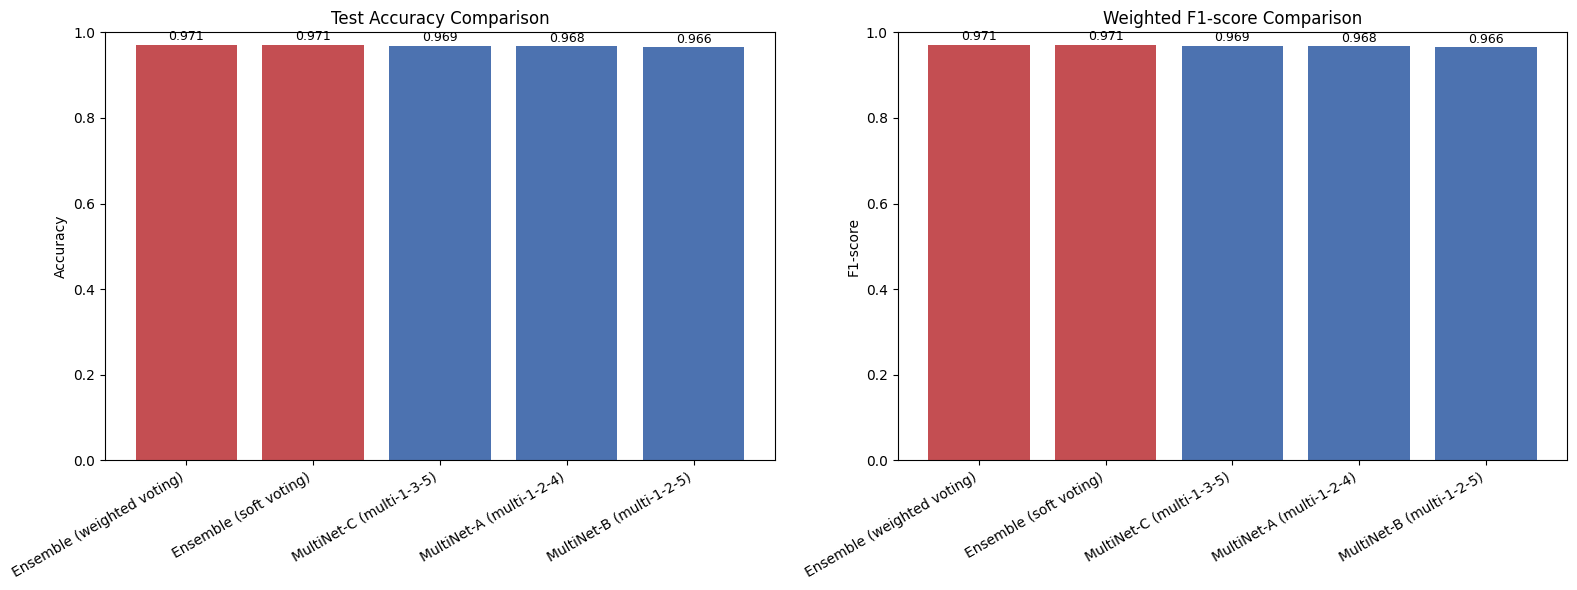

In [9]:
# =========================
# 7a. Accuracy & F1 Bar Charts
# =========================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#4C72B0' if 'Ensemble' not in m else '#C44E52' for m in results_df['model']]

axes[0].bar(results_df['model'], results_df['accuracy'], color=colors)
axes[0].set_title('Test Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=30)
for tick in axes[0].get_xticklabels(): tick.set_ha('right')
for i, v in enumerate(results_df['accuracy']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar(results_df['model'], results_df['f1_weighted'], color=colors)
axes[1].set_title('Weighted F1-score Comparison')
axes[1].set_ylabel('F1-score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=30)
for tick in axes[1].get_xticklabels(): tick.set_ha('right')
for i, v in enumerate(results_df['f1_weighted']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'accuracy_f1_comparison.png', dpi=200)
plt.show()


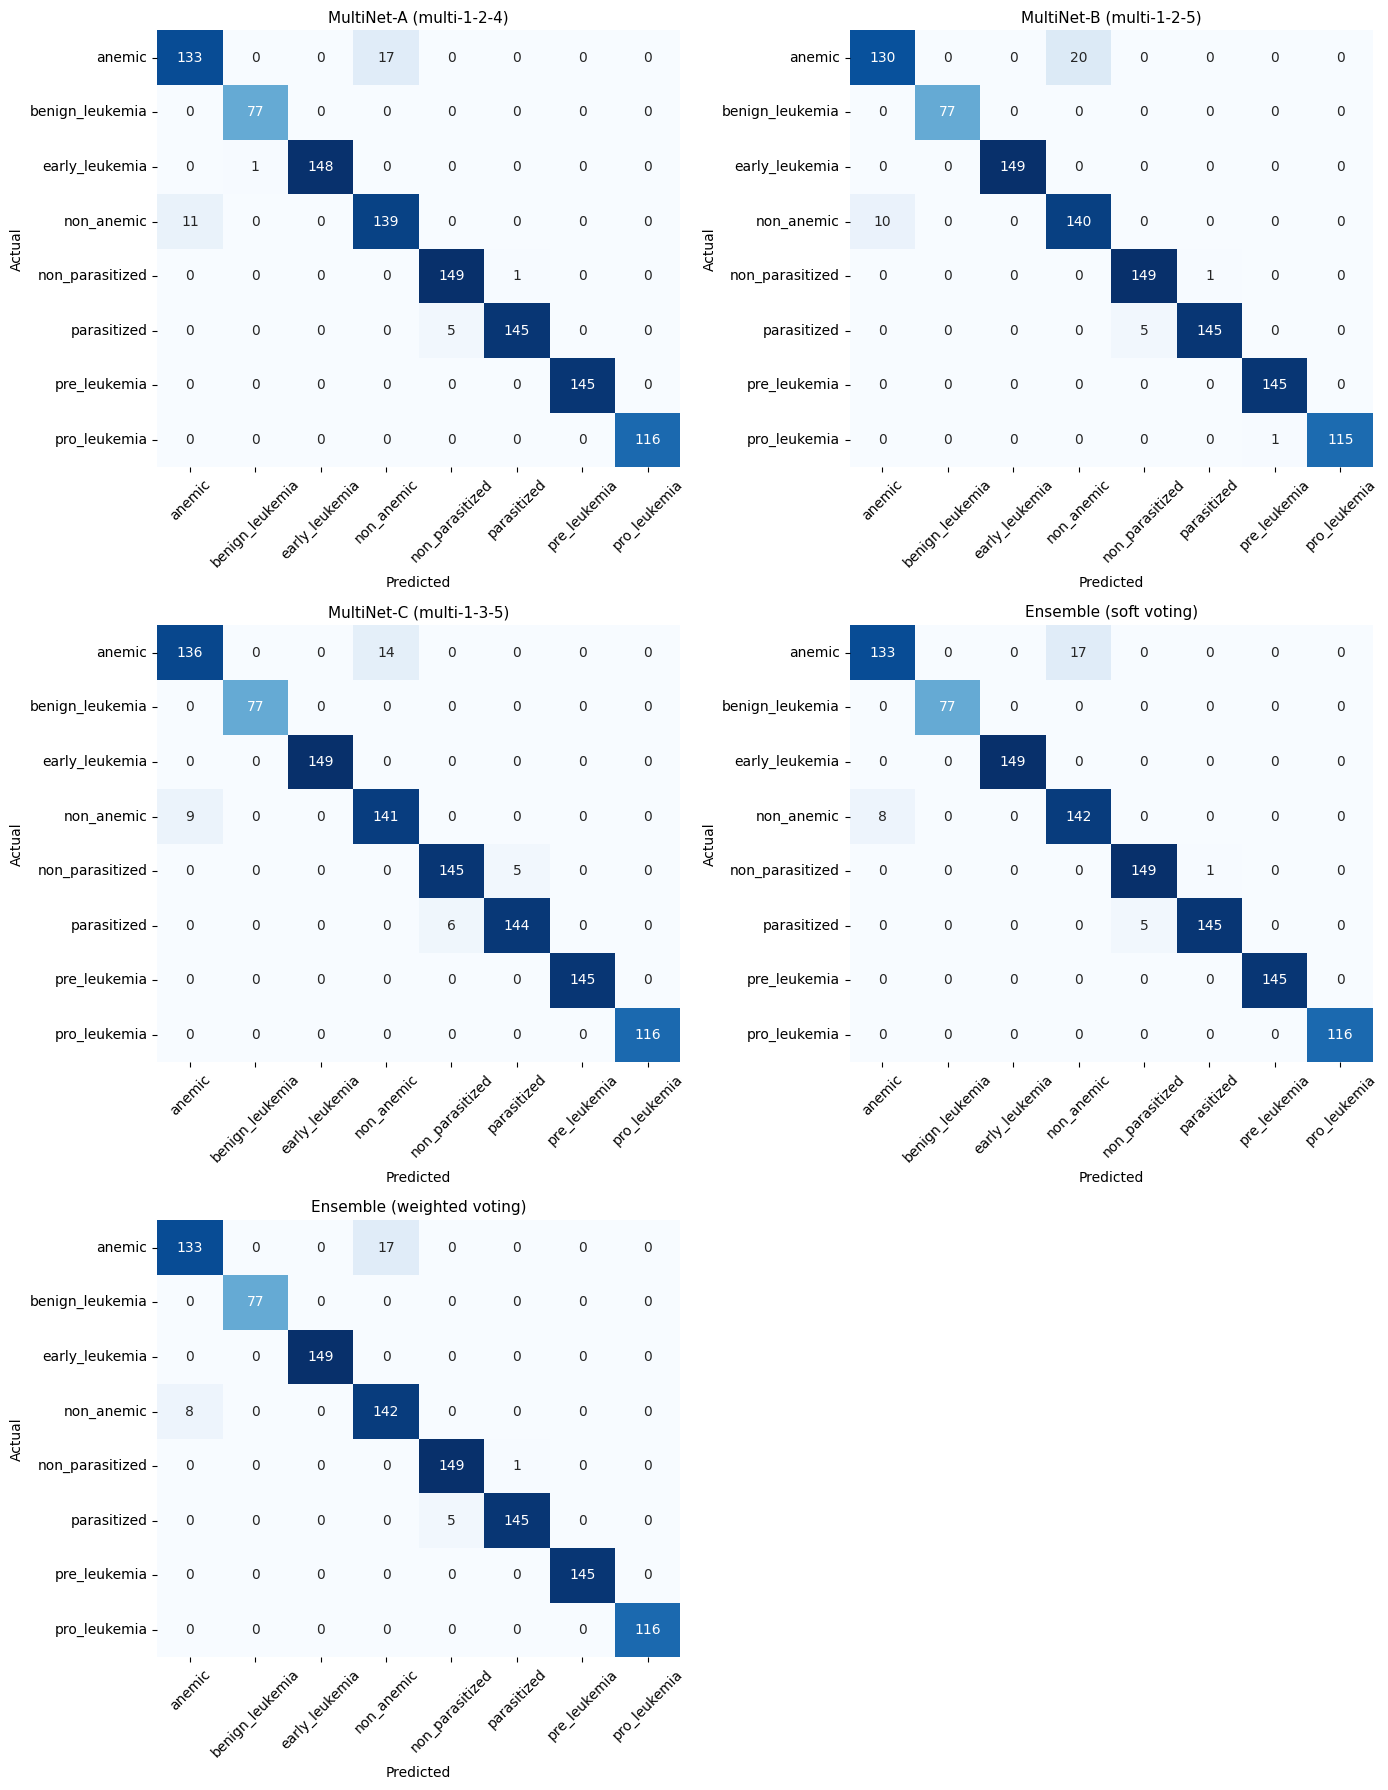

In [10]:
# =========================
# 7b. Confusion Matrices
# =========================
cm_plots = ([(l, model_preds[l]) for l in labels_used]
            + [('Ensemble (soft voting)', soft_vote_preds),
               ('Ensemble (weighted voting)', weighted_vote_preds)])
n_plots = len(cm_plots)
n_cols = 2
n_rows = (n_plots + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (name, preds) in zip(axes, cm_plots):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, ax=ax, cbar=False)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

for ax in axes[len(cm_plots):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'confusion_matrices.png', dpi=200)
plt.show()


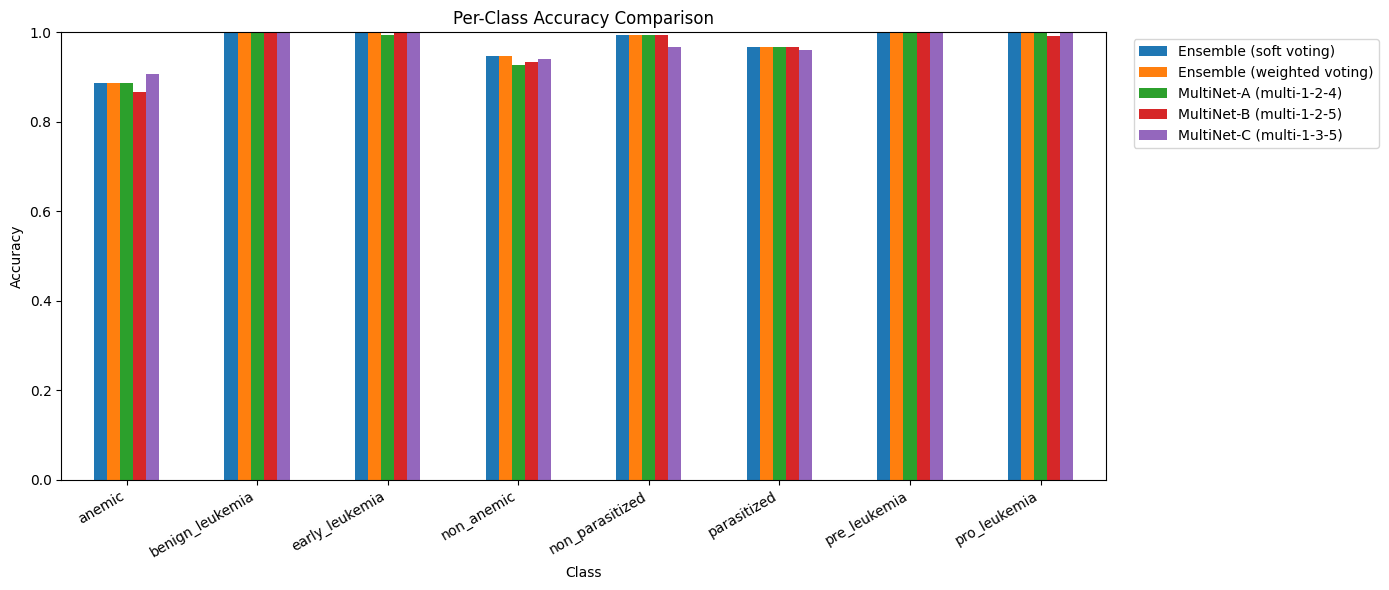

In [11]:
# =========================
# 7c. Per-Class Accuracy Chart
# =========================
per_class_rows = []
for name, preds in cm_plots:
    cm = confusion_matrix(y_true, preds)
    row_sums = cm.sum(axis=1)
    per_class_acc = np.divide(
        cm.diagonal(), row_sums,
        out=np.full(row_sums.shape, np.nan, dtype=float),
        where=row_sums != 0,
    )
    for cls, a in zip(CLASS_NAMES, per_class_acc):
        per_class_rows.append({'model': name, 'class': cls, 'accuracy': a})

per_class_df = pd.DataFrame(per_class_rows)
pivot = per_class_df.pivot(index='class', columns='model', values='accuracy')

pivot.plot(kind='bar', figsize=(14, 6))
plt.title('Per-Class Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Class')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'per_class_accuracy.png', dpi=200)
plt.show()


In [12]:
# =========================
# 8. Save Reports & Summary
# =========================
print('=== Ensemble (soft voting) ===')
print(f'Accuracy: {accuracy_score(y_true, soft_vote_preds):.4f}\n')
soft_report_text = classification_report(y_true, soft_vote_preds, target_names=CLASS_NAMES, zero_division=0)
print(soft_report_text)
with open(ARTIFACT_DIR / 'soft_ensemble_classification_report.txt', 'w') as f:
    f.write(f'Ensemble (soft voting)\nAccuracy: {accuracy_score(y_true, soft_vote_preds):.4f}\n\n')
    f.write(soft_report_text)

print('\n=== Ensemble (weighted voting) ===')
print(f'Accuracy: {accuracy_score(y_true, weighted_vote_preds):.4f}\n')
weighted_report_text = classification_report(y_true, weighted_vote_preds, target_names=CLASS_NAMES, zero_division=0)
print(weighted_report_text)
with open(ARTIFACT_DIR / 'weighted_ensemble_classification_report.txt', 'w') as f:
    f.write(f'Ensemble (weighted voting)\nAccuracy: {accuracy_score(y_true, weighted_vote_preds):.4f}\n\n')
    f.write(weighted_report_text)

summary = {
    'models_evaluated': labels_used,
    'test_set_size': int(len(y_true)),
    'classes': CLASS_NAMES,
    'individual_accuracy': {l: float(accuracy_score(y_true, model_preds[l])) for l in labels_used},
    'weighted_voting_weights': {l: float(w) for l, w in zip(labels_used, weights)},
    'weighted_voting_weight_source': weighting_source,
    'soft_voting_accuracy': float(accuracy_score(y_true, soft_vote_preds)),
    'weighted_voting_accuracy': float(accuracy_score(y_true, weighted_vote_preds)),
}
with open(ARTIFACT_DIR / 'ensemble_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

zip_path = shutil.make_archive(str(WORKING_DIR / 'ensemble_results'), 'zip', ARTIFACT_DIR)
print('Saved all artifacts to:', zip_path)


=== Ensemble (soft voting) ===
Accuracy: 0.9715

                 precision    recall  f1-score   support

         anemic       0.94      0.89      0.91       150
benign_leukemia       1.00      1.00      1.00        77
 early_leukemia       1.00      1.00      1.00       149
     non_anemic       0.89      0.95      0.92       150
non_parasitized       0.97      0.99      0.98       150
    parasitized       0.99      0.97      0.98       150
   pre_leukemia       1.00      1.00      1.00       145
   pro_leukemia       1.00      1.00      1.00       116

       accuracy                           0.97      1087
      macro avg       0.97      0.97      0.97      1087
   weighted avg       0.97      0.97      0.97      1087


=== Ensemble (weighted voting) ===
Accuracy: 0.9715

                 precision    recall  f1-score   support

         anemic       0.94      0.89      0.91       150
benign_leukemia       1.00      1.00      1.00        77
 early_leukemia       1.00      1.00  

In [13]:
# =========================
# Save Model Weight (.pth) Files
# =========================
print("\n--- Saving Model Weights (.pth files) ---")

for label, info in matched.items():
    pth_filename = f"{label}_weights.pth"
    save_pth_path = ARTIFACT_DIR / pth_filename
    
    # Checkpoint থেকে সরাসরি মূল স্টেট ডিক্ট সেভ বা ইন্সট্যান্স মডেলের স্টেট ডিক্ট সেভ
    if 'model_state_dict' in info:
        torch.save(info['model_state_dict'], save_pth_path)
        print(f"Saved {label} weights directly from checkpoint to: {save_pth_path}")
    else:
        # যদি ইনফারেন্সের সময় মডেলের অবজেক্ট তৈরি থাকে
        try:
            temp_model = TrueMultiNet5(NUM_CLASSES, backbone_names=info['backbones'], pretrained=False)
            if 'ckpt_path' in info:
                ckpt = torch.load(info['ckpt_path'], map_location='cpu')
                state_dict = ckpt.get('model_state_dict', ckpt.get('state_dict', ckpt))
                temp_model.load_state_dict(state_dict, strict=False)
            torch.save(temp_model.state_dict(), save_pth_path)
            print(f"Saved {label} weights to: {save_pth_path}")
        except Exception as e:
            print(f"Failed to save {label} model file: {e}")

# Re-create zip archive to include .pth files as well
zip_path = shutil.make_archive(str(WORKING_DIR / 'ensemble_results'), 'zip', ARTIFACT_DIR)
print('Updated full ZIP archive at:', zip_path)


--- Saving Model Weights (.pth files) ---
Saved MultiNet-A (multi-1-2-4) weights to: /kaggle/working/ensemble_artifacts/MultiNet-A (multi-1-2-4)_weights.pth
Saved MultiNet-B (multi-1-2-5) weights to: /kaggle/working/ensemble_artifacts/MultiNet-B (multi-1-2-5)_weights.pth
Saved MultiNet-C (multi-1-3-5) weights to: /kaggle/working/ensemble_artifacts/MultiNet-C (multi-1-3-5)_weights.pth
Updated full ZIP archive at: /kaggle/working/ensemble_results.zip


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ১. Master Ensemble Wrapper Class তৈরি
class FullEnsembleModel(nn.Module):
    def __init__(self, num_classes=8, weights=None):
        super(FullEnsembleModel, self).__init__()
        # ৩টি ব্যাকবোন মডেল ডিক্লেয়ার করা
        self.model_A = TrueMultiNet5(num_classes, backbone_names=['poolformer_s24', 'mobilevit_s', 'xcit_small_12_p16_224'], override_in_features=1536)
        self.model_B = TrueMultiNet5(num_classes, backbone_names=['poolformer_s24', 'mobilevit_s', 'resnet101d'], override_in_features=3200)
        self.model_C = TrueMultiNet5(num_classes, backbone_names=['poolformer_s24', 'densenet169', 'resnet101d'], override_in_features=4224)
        
        # Weighted Voting-এর জন্য ওয়েট (ডিফল্ট ১/৩ করে বা summary.json অনুযায়ী)
        w = weights if weights is not None else [1/3, 1/3, 1/3]
        self.register_buffer('weights', torch.tensor(w, dtype=torch.float32))

    def forward(self, x):
        out_A = F.softmax(self.model_A(x), dim=1)
        out_B = F.softmax(self.model_B(x), dim=1)
        out_C = F.softmax(self.model_C(x), dim=1)
        
        # ৩টি মডেলের প্রেডিকশন ওয়েটেড সাম করা
        final_out = (self.weights[0] * out_A) + (self.weights[1] * out_B) + (self.weights[2] * out_C)
        return final_out

# ২. মাস্টার অবজেক্ট তৈরি এবং ৩টি সেভ হওয়া ওয়েট লোড করা
master_model = FullEnsembleModel(num_classes=NUM_CLASSES)

master_model.model_A.load_state_dict(torch.load(ARTIFACT_DIR / "MultiNet-A (multi-1-2-4)_weights.pth", map_location='cpu'))
master_model.model_B.load_state_dict(torch.load(ARTIFACT_DIR / "MultiNet-B (multi-1-2-5)_weights.pth", map_location='cpu'))
master_model.model_C.load_state_dict(torch.load(ARTIFACT_DIR / "MultiNet-C (multi-1-3-5)_weights.pth", map_location='cpu'))

# ৩. ১টি মাত্র ফাইল হিসেবে সেভ করা
single_pth_path = ARTIFACT_DIR / "ensemble_model.pth"
torch.save(master_model.state_dict(), single_pth_path)

print(f"Single Master Ensemble Model saved successfully at: {single_pth_path}")

Single Master Ensemble Model saved successfully at: /kaggle/working/ensemble_artifacts/ensemble_model.pth
